# Testing our equation to La Jara data 

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Model Functions

In [2]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples (15 minutes in my case)
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    A = 0.2924,
    B = 8.6866,
    multiplicative_factor=1  # factor to adjust k values 
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n:

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False

            # also compute potential τ*c and ratio at initialization timestep
            t = tau_star_vals[i]
            if np.isfinite(t) and np.isfinite(tau_c_current) and tau_c_current > 0:
                ks = 50
                xs = 0.79
                kw = 3.7

                if t / tau_c_current <= 1:
                    tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xs)))
                    tau_pot_pure = tau_conv
                else:
                    tau_pot_pure = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)

                tau_c_pot[i] = tau_pot_pure
                tauc_ratio[i] = t / tau_c_current
            continue

        # forward evolution with our equation
        if i > 0 and not np.isnan(tau_c[i - 1]):  # if previous τ*c is defined, we can evolve
            tau_c_current = tau_c[i - 1]  # determine previous τ*c
        else:
            # τ* present but τ*c not yet initialized
            i += 1
            continue

        t = tau_star_vals[i]  # current τ*

        if not np.isfinite(t) or not np.isfinite(tau_c_current) or tau_c_current <= 0:
            i += 1
            continue

        # sigmoid parameters from flume data
        ks = 50
        xs = 0.79
        kw = 3.7

        if t / tau_c_current <= 1:  # if τ* is below max τ*c, equilibrium is the max of current τ*c and convergence function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xs)))
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        # calculate k (function of applied tau*)
        k = A * (t / tau_c_max) ** B

        # new tau_c evolution equation
        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_c[i] = tau_pot - (tau_pot - tau_c_current) * np.exp(-k * multiplicative_factor * dt)

        # ratio defined against evolved τ*c at this same timestep
        if np.isfinite(tau_c[i]) and tau_c[i] > 0:
            tauc_ratio[i] = t / tau_c[i]
        #print('tauc at time:', i, 'is', tau_c[i], '. tau_pot is', tau_c_pot[i], 'and tau/tauc', tauc_ratio[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

parameter calibration 

In [3]:
def calibrate_parameters(
    tau_star,
    event_indices,      # indices of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    tau_c_max,
    tau_c_min,
    A_vals,             # candidate values for parameter A
    B_vals,             # candidate values for parameter B
):
    
    """
    Grid-search calibration of the model using mean absolute error (MAE).
    """
    results = []
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    
    # iterate through minimum τ*c values, and A and B parameters
    for a_idx, A in enumerate(A_vals):
        print(f"Testing A = {A:.6e} ({a_idx + 1}/{len(A_vals)})")
        for b_idx, B in enumerate(B_vals):
            print(f"Testing B = {B:.6e} ({b_idx + 1}/{len(B_vals)})")
            tau_c_model, *_ = evolve_tauc_tc(
                tau_star=tau_star,
                dt=dt,
                tau_c_min=tau_c_min,
                tau_c_max=tau_c_max,
                event_indices=event_indices,
                tau_c_obs=tau_c_obs,
                A=A,
                B=B,
            )

            # extract modeled τ*c at event starts
            if isinstance(tau_star, pd.Series):
                tau_c_series = pd.Series(tau_c_model, index=tau_star.index)
                tau_c_pred = tau_c_series.reindex(event_indices).to_numpy(dtype=float)
            else:
                event_pos = np.asarray(event_indices, dtype=int)
                tau_c_pred = np.asarray(tau_c_model, dtype=float)[event_pos]

            # calculate mean absolute error (paper uses MAE), and ignore NaNs
            mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs_arr))
            results.append({
                "A": A,
                "B": B,
                "MAE": mae
            })

    expected = len(A_vals) * len(B_vals)
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected} calibration rows, got {len(results)}")

    return results

In [4]:
def calibrate_multiplicative_factor(
    tau_star,
    event_indices,      # indices of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    tau_c_max,
    tau_c_min,
    multiplicative_factors,
):
    
    """
    Grid-search calibration of the model using mean absolute error (MAE).
    """
    results = []
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    
        # iterate through minimum τ*c values, and A and B parameters
    for mf_idx, multiplicative_factor in enumerate(multiplicative_factors):
        print(f"Testing multiplicative_factor = {multiplicative_factor:.6e} ({mf_idx + 1}/{len(multiplicative_factors)})")  
        tau_c_model, *_ = evolve_tauc_tc(
            tau_star=tau_star,
            dt=dt,
            tau_c_min=tau_c_min,
            tau_c_max=tau_c_max,
            event_indices=event_indices,
            tau_c_obs=tau_c_obs,
            multiplicative_factor=multiplicative_factor,
        )

        # extract modeled τ*c at event starts
        if isinstance(tau_star, pd.Series):
            tau_c_series = pd.Series(tau_c_model, index=tau_star.index)
            tau_c_pred = tau_c_series.reindex(event_indices).to_numpy(dtype=float)
        else:
            event_pos = np.asarray(event_indices, dtype=int)
            tau_c_pred = np.asarray(tau_c_model, dtype=float)[event_pos]

        # calculate mean absolute error (paper uses MAE), and ignore NaNs
        mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs_arr))
        results.append({
            "multiplicative_factor": multiplicative_factor,
            "MAE": mae
        })

    expected = len(multiplicative_factors)
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected} calibration rows, got {len(results)}")

    return results

parameter ranges

In [12]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 100) # values evenly spaced on log scale
B_vals = np.linspace(1, 10, 50) # values from 0 to 10
multiplicative_factors = np.logspace(-7, 0, 100) # values from 0.0001 to 1 on log scale

import data

In [13]:
# import data 
tau_star = pd.read_csv('../../../shear_stress_record/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('../field_data/tauc_events_exceedance_rising.csv', parse_dates=['datetime'], index_col='datetime')
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')
# create continuous 15-minute time index from first timestamp to last
continuous_index = pd.date_range(start=tau_star.index.min(), end=tau_star.index.max(), freq='15min')
# change column name to 'tau' for clarity
df_tau = tau_star.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau = df_tau[df_tau.index >= '2022-07-14 15:00']


print(f"Data gaps (NaNs): {df_tau['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau[df_tau['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau['tau_star'] = df_tau['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau)), 
    index=df_tau.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau.index[1] - df_tau.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq=None)
Calculated dt: 15.0 minutes


### 2) Measured min and max

2.1) Testing Multiplicative Factor

In [14]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# find min and max of τ*c observations 
tauc_min_lajara = tauc_obs_lajara.min() 
tauc_max_lajara = tauc_obs_lajara.max() 

In [47]:
calibration = calibrate_multiplicative_factor(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    multiplicative_factors=multiplicative_factors,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing multiplicative_factor = 1.000000e-07 (1/100)
Testing multiplicative_factor = 1.176812e-07 (2/100)
Testing multiplicative_factor = 1.384886e-07 (3/100)
Testing multiplicative_factor = 1.629751e-07 (4/100)
Testing multiplicative_factor = 1.917910e-07 (5/100)
Testing multiplicative_factor = 2.257020e-07 (6/100)
Testing multiplicative_factor = 2.656088e-07 (7/100)
Testing multiplicative_factor = 3.125716e-07 (8/100)
Testing multiplicative_factor = 3.678380e-07 (9/100)
Testing multiplicative_factor = 4.328761e-07 (10/100)
Testing multiplicative_factor = 5.094138e-07 (11/100)
Testing multiplicative_factor = 5.994843e-07 (12/100)
Testing multiplicative_factor = 7.054802e-07 (13/100)
Testing multiplicative_factor = 8.302176e-07 (14/100)
Testing multiplicative_factor = 9.770100e-07 (15/100)
Testing multiplicative_factor = 1.149757e-06 (16/100)
Testing multiplicative_factor = 1.353048e-06 (17/100)
Testing multiplicative_factor = 1.592283e-06 (18/100)
Testing multiplicative_factor = 1.873

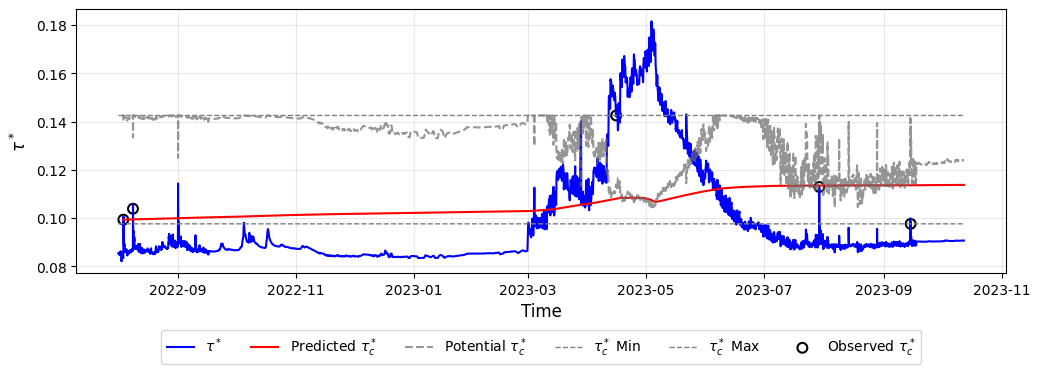

In [48]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    multiplicative_factor=best["multiplicative_factor"]
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
# place legend centered below the x-axis
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.37), ncol=6)
ax.grid(True, alpha=0.3)

# leave room for the legend below the axis
plt.subplots_adjust(bottom=0.22)
plt.show()

Best MAE: 0.011099
10% threshold (<=): 0.012209
Parameter sets within threshold: 15 / 100


,multiplicative_factor,MAE
0,0.000079,0.011099
1,0.000067,0.011106
2,0.000093,0.011256
3,0.000057,0.011321
4,0.000110,0.011416
5,0.000049,0.011507
6,0.000129,0.011585
7,0.000041,0.011668
8,0.000152,0.011776
9,0.000035,0.011805


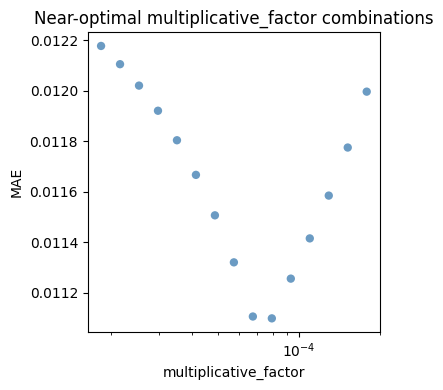

In [49]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["multiplicative_factor", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "../parameter_sensitivity_analysis/2_field_multiplicative_factors_within10pct_MAE.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal multiplicative_factor cloud.
if "multiplicative_factor" in near_optimal.columns:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(
        near_optimal["multiplicative_factor"],
        near_optimal[mae_col],
        edgecolors="none",
        color="steelblue",
        alpha=0.8,
    )
    ax.set_xscale("log")
    ax.set_xlabel("multiplicative_factor")
    ax.set_ylabel(mae_col)
    ax.set_title("Near-optimal multiplicative_factor combinations")

    plt.tight_layout()
    plt.show()

2.2) Testing A & b

In [26]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/100)
Testing B = 1.000000e+00 (1/50)
Testing B = 1.183673e+00 (2/50)
Testing B = 1.367347e+00 (3/50)
Testing B = 1.551020e+00 (4/50)
Testing B = 1.734694e+00 (5/50)
Testing B = 1.918367e+00 (6/50)
Testing B = 2.102041e+00 (7/50)
Testing B = 2.285714e+00 (8/50)
Testing B = 2.469388e+00 (9/50)
Testing B = 2.653061e+00 (10/50)
Testing B = 2.836735e+00 (11/50)
Testing B = 3.020408e+00 (12/50)
Testing B = 3.204082e+00 (13/50)
Testing B = 3.387755e+00 (14/50)
Testing B = 3.571429e+00 (15/50)
Testing B = 3.755102e+00 (16/50)
Testing B = 3.938776e+00 (17/50)
Testing B = 4.122449e+00 (18/50)
Testing B = 4.306122e+00 (19/50)
Testing B = 4.489796e+00 (20/50)
Testing B = 4.673469e+00 (21/50)
Testing B = 4.857143e+00 (22/50)
Testing B = 5.040816e+00 (23/50)
Testing B = 5.224490e+00 (24/50)
Testing B = 5.408163e+00 (25/50)
Testing B = 5.591837e+00 (26/50)
Testing B = 5.775510e+00 (27/50)
Testing B = 5.959184e+00 (28/50)
Testing B = 6.142857e+00 (29/50)
Testing B = 6.32653

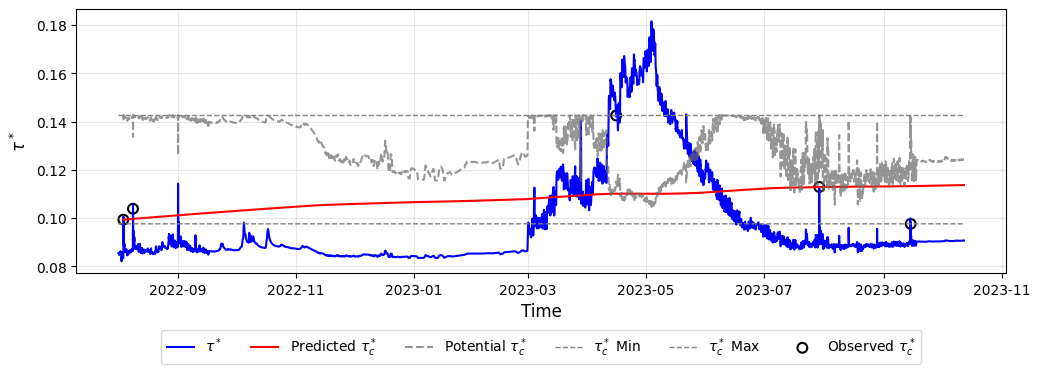

In [45]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"]
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
# place legend centered below the x-axis
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.37), ncol=6)
ax.grid(True, alpha=0.3)

# leave room for the legend below the axis
plt.subplots_adjust(bottom=0.22)
plt.show()

Best MAE: 0.010454
15% threshold (<=): 0.012022
Parameter sets within threshold: 882 / 5000

Top 30 by MAE:


,A,B,MAE
0,0.000002,1.000000,0.010454
1,0.000002,1.367347,0.010469
2,0.000002,1.734694,0.010483
3,0.000003,2.102041,0.010496
4,0.000003,2.469388,0.010507
5,0.000002,1.183673,0.010521
6,0.000004,2.836735,0.010527
7,0.000002,1.551020,0.010539
8,0.000004,3.204082,0.010554
9,0.000003,1.918367,0.010559


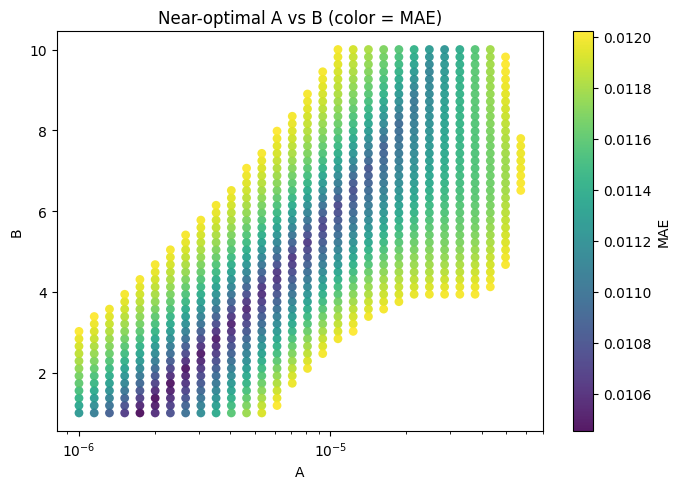

In [46]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.15

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"15% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "../parameter_sensitivity_analysis/2_field_parameter_sets_within10pct_MAE.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal A vs B cloud (colorbar included)
if {"A", "B"}.issubset(near_optimal.columns):
    fig, ax = plt.subplots(figsize=(7, 5))

    sc = ax.scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=40,
        edgecolors="none",
        alpha=0.9,
    )
    ax.set_xscale("log")
    ax.set_xlabel("A")
    ax.set_ylabel("B")
    ax.set_title("Near-optimal A vs B (color = MAE)")

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(mae_col)

    plt.tight_layout()
    plt.show()

### 3) Estimated min and max

3.1) Testing Multiplicative Factor

In [50]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# τ*c min and max from equations in Masteller 2025
tauc_min_lajara = 0.0343
tauc_max_lajara = 0.3435

In [51]:
calibration = calibrate_multiplicative_factor(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    multiplicative_factors=multiplicative_factors,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing multiplicative_factor = 1.000000e-07 (1/100)
Testing multiplicative_factor = 1.176812e-07 (2/100)
Testing multiplicative_factor = 1.384886e-07 (3/100)
Testing multiplicative_factor = 1.629751e-07 (4/100)
Testing multiplicative_factor = 1.917910e-07 (5/100)
Testing multiplicative_factor = 2.257020e-07 (6/100)
Testing multiplicative_factor = 2.656088e-07 (7/100)
Testing multiplicative_factor = 3.125716e-07 (8/100)
Testing multiplicative_factor = 3.678380e-07 (9/100)
Testing multiplicative_factor = 4.328761e-07 (10/100)
Testing multiplicative_factor = 5.094138e-07 (11/100)
Testing multiplicative_factor = 5.994843e-07 (12/100)
Testing multiplicative_factor = 7.054802e-07 (13/100)
Testing multiplicative_factor = 8.302176e-07 (14/100)
Testing multiplicative_factor = 9.770100e-07 (15/100)
Testing multiplicative_factor = 1.149757e-06 (16/100)
Testing multiplicative_factor = 1.353048e-06 (17/100)
Testing multiplicative_factor = 1.592283e-06 (18/100)
Testing multiplicative_factor = 1.873

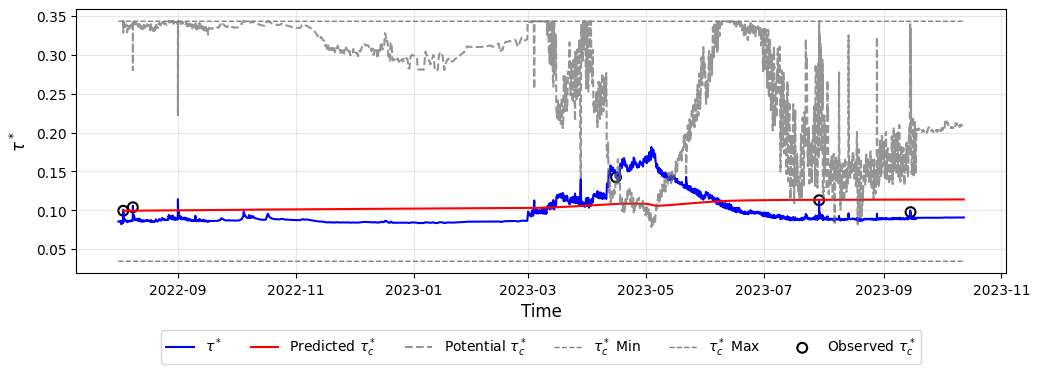

In [52]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    multiplicative_factor=best["multiplicative_factor"]
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
# place legend centered below the x-axis
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.37), ncol=6)
ax.grid(True, alpha=0.3)

# leave room for the legend below the axis
plt.subplots_adjust(bottom=0.22)
plt.show()

Best MAE: 0.011104
10% threshold (<=): 0.012215
Parameter sets within threshold: 8 / 100


,multiplicative_factor,MAE
0,0.027826,0.011104
1,0.023645,0.011247
2,0.020092,0.011509
3,0.017074,0.011704
4,0.014508,0.011857
5,0.012328,0.011979
6,0.010476,0.012080
7,0.008902,0.012162


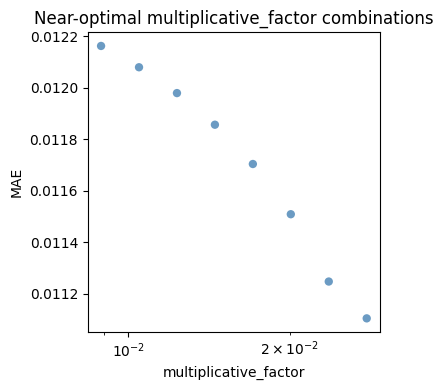

In [ ]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["multiplicative_factor", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "../parameter_sensitivity_analysis/4_field_multiplicative_factors_within10pct_MAE.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal multiplicative_factor cloud.
if "multiplicative_factor" in near_optimal.columns:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(
        near_optimal["multiplicative_factor"],
        near_optimal[mae_col],
        edgecolors="none",
        color="steelblue",
        alpha=0.8,
    )
    ax.set_xscale("log")
    ax.set_xlabel("multiplicative_factor")
    ax.set_ylabel(mae_col)
    ax.set_title("Near-optimal multiplicative_factor combinations")

    plt.tight_layout()
    plt.show()

3.2) Testing A & b

In [54]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/100)
Testing B = 1.000000e+00 (1/50)
Testing B = 1.183673e+00 (2/50)
Testing B = 1.367347e+00 (3/50)
Testing B = 1.551020e+00 (4/50)
Testing B = 1.734694e+00 (5/50)
Testing B = 1.918367e+00 (6/50)
Testing B = 2.102041e+00 (7/50)
Testing B = 2.285714e+00 (8/50)
Testing B = 2.469388e+00 (9/50)
Testing B = 2.653061e+00 (10/50)
Testing B = 2.836735e+00 (11/50)
Testing B = 3.020408e+00 (12/50)
Testing B = 3.204082e+00 (13/50)
Testing B = 3.387755e+00 (14/50)
Testing B = 3.571429e+00 (15/50)
Testing B = 3.755102e+00 (16/50)
Testing B = 3.938776e+00 (17/50)
Testing B = 4.122449e+00 (18/50)
Testing B = 4.306122e+00 (19/50)
Testing B = 4.489796e+00 (20/50)
Testing B = 4.673469e+00 (21/50)
Testing B = 4.857143e+00 (22/50)
Testing B = 5.040816e+00 (23/50)
Testing B = 5.224490e+00 (24/50)
Testing B = 5.408163e+00 (25/50)
Testing B = 5.591837e+00 (26/50)
Testing B = 5.775510e+00 (27/50)
Testing B = 5.959184e+00 (28/50)
Testing B = 6.142857e+00 (29/50)
Testing B = 6.32653

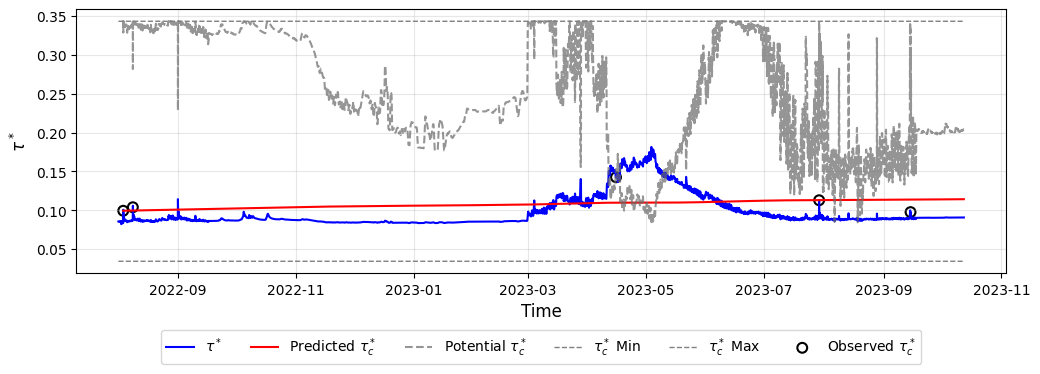

In [55]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"]
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
# place legend centered below the x-axis
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.37), ncol=6)
ax.grid(True, alpha=0.3)

# leave room for the legend below the axis
plt.subplots_adjust(bottom=0.22)
plt.show()

Best MAE: 0.010661
15% threshold (<=): 0.012260
Parameter sets within threshold: 583 / 5000

Top 30 by MAE:


,A,B,MAE
0,0.000001,1.367347,0.010661
1,0.000002,1.734694,0.010681
2,0.000003,2.285714,0.010700
3,0.000002,1.918367,0.010700
4,0.000006,2.836735,0.010714
5,0.000012,3.387755,0.010738
6,0.000004,2.469388,0.010750
7,0.000001,1.551020,0.010759
8,0.000001,1.551020,0.010768
9,0.000002,2.102041,0.010782


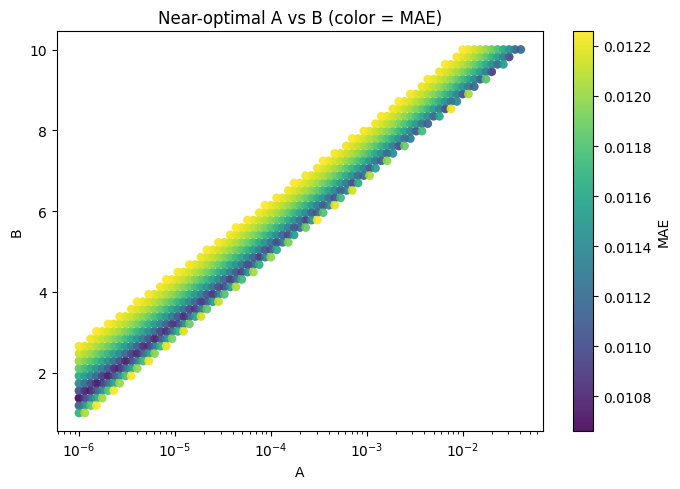

In [56]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.15

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"15% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "../parameter_sensitivity_analysis/3_field_parameter_sets_within10pct_MAE.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal A vs B cloud (colorbar included)
if {"A", "B"}.issubset(near_optimal.columns):
    fig, ax = plt.subplots(figsize=(7, 5))

    sc = ax.scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=40,
        edgecolors="none",
        alpha=0.9,
    )
    ax.set_xscale("log")
    ax.set_xlabel("A")
    ax.set_ylabel("B")
    ax.set_title("Near-optimal A vs B (color = MAE)")

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(mae_col)

    plt.tight_layout()
    plt.show()